In [1]:
##imports
from Rotor import Rotor
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, List, Literal
from pathlib import Path

from globals import main_dir,data_dir, plot_dir, res_dir
import plotting_routines

import pandas as pd



In [2]:
J = [1.6, 2, 2.4]
R = 0.7
dfs = []

In [3]:

# for i, j in enumerate(J):
#     Vinf = np.array([60,0,0])
#     n = Vinf[0]/(j*2*R)
#     Ome  = n*2*np.pi
#     Vinf_wing = np.array([1,0,0])
#     c_R_func:Callable = lambda r_R : 0.18-0.06*r_R
#     twst_func:Callable = lambda r_R : -50*r_R+35

#     wing_c_R_func:Callable = lambda r_R: np.ones(shape=r_R.shape)/10 #=1
#     wing_twst_func:Callable = lambda r_R : r_R*0
#     rotor = Rotor(B=6,
#                     R=R,
#                     r_R_H=0.25,
#                     c_R_func=c_R_func,
#                     twst_func=twst_func,
#                     pitch=45,
#                     polar_path=data_dir.joinpath("ARAD8pct_polar.txt"),
#                     Omega = Ome,
#                     Vinf=Vinf,
#                     rho=1.067,
#                     n_elem=40,
#                     dist_elem="uniform",
#                     periods = 1,
#                     n_elems_per_wake=10
#                     )

#     rotor.solve(tol = 1e-6,step_size=0.01,max_iter =10000)
#     # Define result filename
#     fname = res_dir.joinpath(f'LLM_span_dist_J_{j:.1f}.csv')
#     # rotor.solve(tol = 1e-6,step_size=0.01,max_iter =10000)
#     rotor.export_dist(fname)
#     # Read distribution
#     dfs.append(pd.read_csv(fname, sep=r","))   


In [4]:
#If already generated, read the dataframes
dfs.append(pd.read_csv(res_dir.joinpath('LLM_span_dist_J_1.6.csv'), sep=r",")) 
dfs.append(pd.read_csv(res_dir.joinpath('LLM_span_dist_J_2.0.csv'), sep=r",")) 
dfs.append(pd.read_csv(res_dir.joinpath('LLM_span_dist_J_2.4.csv'), sep=r","))

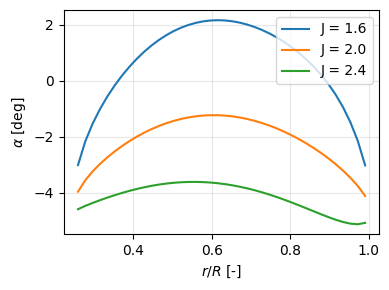

In [5]:
#Angle of attack
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('alpha', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_alpha.pdf"))


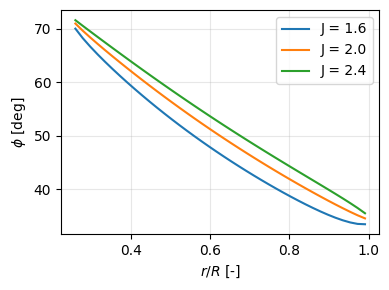

In [6]:
#Inflow anlge
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('phi', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_phi.pdf"))

In [7]:
#Axial induction factor #TODO need to implement in the code first

In [8]:
#Azimuthal induction factor #TODO need to implement in the code first

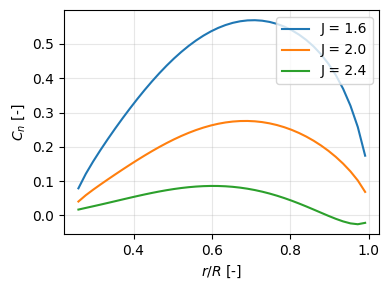

In [9]:
#Axial loading Cx
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('Cx', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_Cx.pdf"))

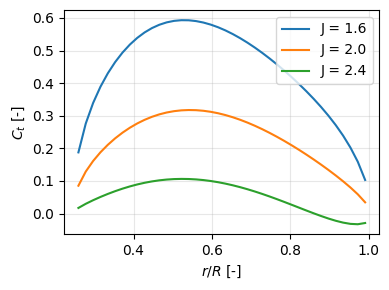

In [10]:
#Azimuthal loading Cy
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('Cy', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_Cy.pdf"))

In [11]:
#Total thrust coeficient #TODO need to implement in the code first

In [12]:
#Total Power coeficient #TODO need to implement in the code first

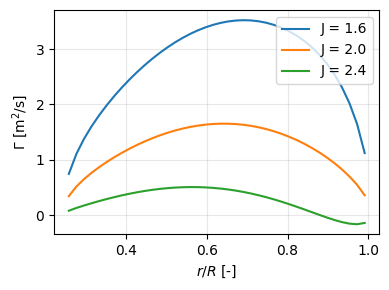

In [13]:
#Distribution of the circulation(Gamma) along the blade span 
fig, ax = plt.subplots(figsize=(4,3))

for df, j in zip(dfs, J):
    plotting_routines.distribution('gamma', df, ax, label=f'J = {j:.1f}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("span_dist_Gamma.pdf"))

### LLM and BEM Comparison ###

In [14]:

model = ["LLM", "BEM"]
comp_df = []
comp_df.append(pd.read_csv(res_dir.joinpath('LLM_span_dist_J_2.0.csv'), sep=r",")) 
comp_df.append(pd.read_csv(res_dir.joinpath('BEM_span_dist_J_2.0.csv'), sep=r",")) 

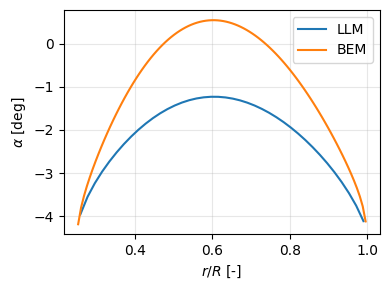

In [15]:
#Angle of attack
fig, ax = plt.subplots(figsize=(4,3))

for df, mod in zip(comp_df, model):
    plotting_routines.distribution('alpha', df, ax, label=f'{mod}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("Comparision_span_dist_alpha.pdf"))


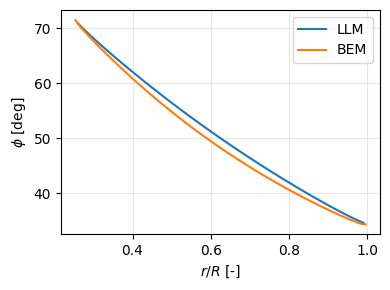

In [16]:
#PHI of attack
fig, ax = plt.subplots(figsize=(4,3))

for df, mod in zip(comp_df, model):
    plotting_routines.distribution('phi', df, ax, label=f'{mod}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("Comparision_span_dist_Phi.pdf"))

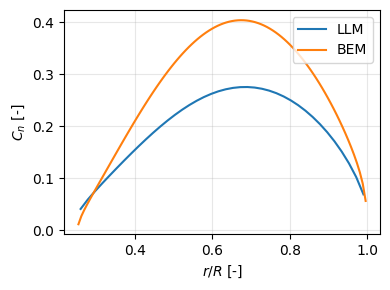

In [17]:
#Axial loading coefficient
fig, ax = plt.subplots(figsize=(4,3))

for df, mod in zip(comp_df, model):
    plotting_routines.distribution('Cx', df, ax, label=f'{mod}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("Comparision_span_dist_Cx.pdf"))

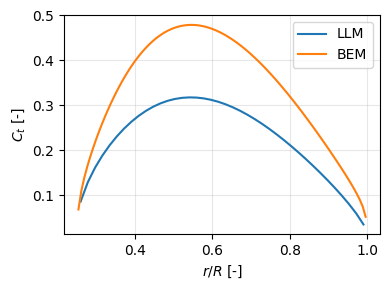

In [18]:
#Tangential loading coefficient
fig, ax = plt.subplots(figsize=(4,3))

for df, mod in zip(comp_df, model):
    plotting_routines.distribution('Cy', df, ax, label=f'{mod}')

ax.legend(loc='upper right')
fig.tight_layout()

fig.savefig(plot_dir.joinpath("Comparision_span_dist_Cy.pdf"))

In [ ]:
#TODO implement induction factors